# Credit Card Approval — Local Development Notebook

Local version of the MLOps training pipeline. Mirrors the logic in `scripts/train_model.py` and `scripts/evaluate_model.py` without any AWS dependencies.

**What this notebook does:**
1. Loads and explores the synthetic credit card dataset
2. Trains a RandomForest classifier (same algorithm as production)
3. Computes quality metrics and fairness metrics (same thresholds as production gate)
4. Visualises feature importances and performance
5. Runs the quality gate assertions — fails loudly if any threshold is violated
6. Saves model and metrics to `outputs/` for local API testing
7. Tracks the run with MLFlow (local file store)

**Not in this notebook (handled by the Harness pipeline):**
- SageMaker Experiments / Model Registry
- S3 artifact upload
- Docker image build / push
- Kubernetes deployment

## 1. Setup

In [1]:
import os
import json
import yaml
import joblib
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, confusion_matrix
)

# Navigate to repo root so all relative paths (configs/, data/, outputs/) work correctly
repo_root = pathlib.Path(os.getcwd())
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
    os.chdir(repo_root)

print(f"Working directory: {os.getcwd()}")

/Users/anandrai/Documents/CustomerConfigurations/AIProjects/harness mlops pipeline/ml-ops/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working directory: /Users/anandrai/Documents/CustomerConfigurations/AIProjects/harness mlops pipeline/ml-ops


In [2]:
# Load config
with open('configs/config.yml') as f:
    config = yaml.safe_load(f)

DATA_PATH        = config['data']['load_file_path']
OUTPUT_DIR       = config['model']['model_output_file_path']
MODEL_FILE       = config['model']['model_output_file']
MLFLOW_URI       = config['mlflow']['tracking_uri']
EXPERIMENT_NAME  = config['mlflow']['experiment_name']
IMAGE_DIR        = config['images']['image_output_file_path']

N_ESTIMATORS = 100   # matches pipeline default

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

print(f"Data   : {DATA_PATH}")
print(f"Outputs: {OUTPUT_DIR}")
print(f"MLFlow : {MLFLOW_URI}")

Data   : data/raw/synthetic_credit_card_approval.csv
Outputs: outputs
MLFlow : https://mlflow.sandbox.harness-demo.site


## 2. Load & Explore Data

In [3]:
data = pd.read_csv(DATA_PATH)
print(f"Shape: {data.shape}")
data.head()

Shape: (500000, 6)


,Num_Children,Group,Income,Own_Car,Own_Housing,Target
0,4,0,36151,0,0,0
1,0,0,36095,1,0,0
2,2,1,62110,1,1,0
3,0,1,73644,1,0,0
4,3,0,99146,0,0,1


In [4]:
print("Target distribution:")
print(data['Target'].value_counts(normalize=True).rename({0: 'Rejected', 1: 'Approved'}).map('{:.1%}'.format))
print()
print("Group distribution:")
print(data['Group'].value_counts(normalize=True).map('{:.1%}'.format))
print()
print(data.describe())

Target distribution:
Target
Rejected    61.3%
Approved    38.7%
Name: proportion, dtype: object

Group distribution:
Group
1    50.1%
0    49.9%
Name: proportion, dtype: object

        Num_Children         Group         Income        Own_Car  \
count  500000.000000  500000.00000  500000.000000  500000.000000   
mean        2.000346       0.50065   72507.446898       0.700930   
std         1.410574       0.50000   22960.209440       0.457851   
min         0.000000       0.00000   30000.000000       0.000000   
25%         1.000000       0.00000   53321.000000       0.000000   
50%         2.000000       1.00000   72060.000000       1.000000   
75%         3.000000       1.00000   90670.250000       1.000000   
max        11.000000       1.00000  119999.000000       1.000000   

         Own_Housing         Target  
count  500000.000000  500000.000000  
mean        0.401612       0.386626  
std         0.490225       0.486977  
min         0.000000       0.000000  
25%         0.00000

## 3. Prepare Features

Training features: `Num_Children`, `Income`, `Own_Car`, `Own_Housing`

`Group` is the sensitive demographic attribute — extracted for fairness evaluation only, **not used as a training feature** (fairness-unaware model by design).

In [5]:
# Separate sensitive attribute before splitting
group = data['Group'] if 'Group' in data.columns else pd.Series(['unknown'] * len(data))

# Drop target and Group — Group is fairness-only, not a training feature
X = data.drop(columns=['Target', 'Group'], errors='ignore')
y = data['Target']

print(f"Training features: {list(X.columns)}")
print(f"Feature order passed to model: {list(X.columns)}")
print(f"Samples: {len(X):,}")

Training features: ['Num_Children', 'Income', 'Own_Car', 'Own_Housing']
Feature order passed to model: ['Num_Children', 'Income', 'Own_Car', 'Own_Housing']
Samples: 500,000


In [6]:
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X, y, group, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 400,000  |  Test: 100,000


## 4. Train Model

In [7]:
model = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print("Training complete.")

Training complete.


## 5. Compute Metrics

Same metric functions as `scripts/train_model.py` — no noise added.

In [8]:
def get_metrics(y_true, y_pred):
    return {
        'precision': precision_score(y_true, y_pred, average='weighted'),
        'recall':    recall_score(y_true, y_pred, average='weighted'),
        'f1':        f1_score(y_true, y_pred, average='weighted'),
        'accuracy':  accuracy_score(y_true, y_pred),
    }


def get_fairness_metrics(y_pred, group_labels):
    """Approval-rate parity across demographic groups — matches production gate."""
    metrics = {}
    approval_rates = []
    for grp_val in sorted(group_labels.unique()):
        mask = group_labels.values == grp_val
        rate = float(pd.Series(y_pred)[mask].mean())
        metrics[f'fairness_group_{grp_val}_approval_rate'] = rate
        approval_rates.append(rate)
    metrics['fairness_gap'] = (
        max(approval_rates) - min(approval_rates) if len(approval_rates) >= 2 else 0.0
    )
    return metrics


def get_feature_importances(X, y):
    forest = RandomForestClassifier(random_state=0)
    forest.fit(X, y)
    return pd.Series(forest.feature_importances_, index=X.columns).to_dict()


train_metrics = get_metrics(y_train, y_train_pred)
test_metrics  = get_metrics(y_test,  y_test_pred)
fairness      = get_fairness_metrics(y_test_pred, group_test)
importances   = get_feature_importances(X_train, y_train)

print("Train metrics:")
for k, v in train_metrics.items(): print(f"  {k:<12} {v:.4f}")
print()
print("Test metrics:")
for k, v in test_metrics.items():  print(f"  {k:<12} {v:.4f}")
print()
print("Fairness metrics:")
for k, v in fairness.items():      print(f"  {k:<45} {v:.4f}")

Train metrics:
  precision    0.9888
  recall       0.9888
  f1           0.9888
  accuracy     0.9888

Test metrics:
  precision    0.9207
  recall       0.9206
  f1           0.9206
  accuracy     0.9206

Fairness metrics:
  fairness_group_0_approval_rate                0.2595
  fairness_group_1_approval_rate                0.5171
  fairness_gap                                  0.2576


## 6. Visualise

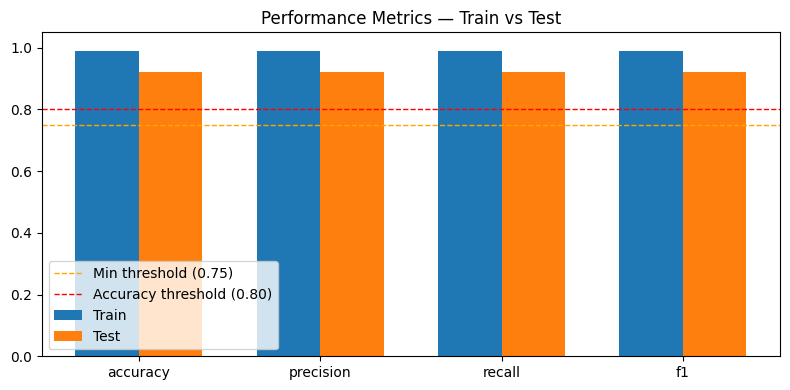

In [9]:
# Performance metrics — train vs test
metrics_names = ['accuracy', 'precision', 'recall', 'f1']
train_vals = [train_metrics[m] for m in metrics_names]
test_vals  = [test_metrics[m]  for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, train_vals, width, label='Train')
ax.bar(x + width/2, test_vals,  width, label='Test')
ax.axhline(0.75, color='orange', linestyle='--', linewidth=1, label='Min threshold (0.75)')
ax.axhline(0.80, color='red',    linestyle='--', linewidth=1, label='Accuracy threshold (0.80)')
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_title('Performance Metrics — Train vs Test')
ax.legend()
fig.tight_layout()
plt.savefig(f"{IMAGE_DIR}/performance_metrics_by_train_and_test.jpg", bbox_inches='tight')
plt.show()

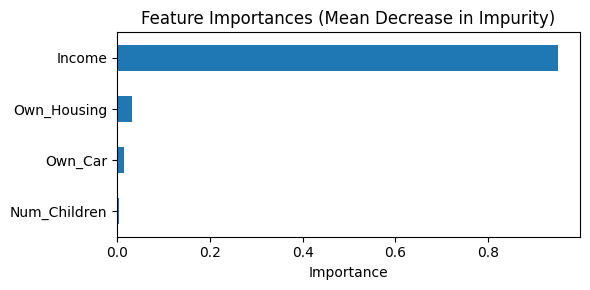

In [10]:
# Feature importances
imp_series = pd.Series(importances).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(6, 3))
imp_series.plot.barh(ax=ax)
ax.set_title('Feature Importances (Mean Decrease in Impurity)')
ax.set_xlabel('Importance')
fig.tight_layout()
plt.savefig(f"{IMAGE_DIR}/feature_importances.jpg", bbox_inches='tight')
plt.show()

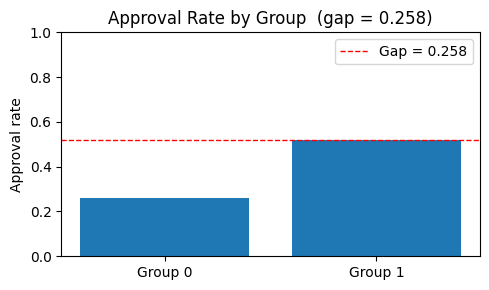

In [11]:
# Fairness — approval rates by group
group_keys = [k for k in fairness if 'approval_rate' in k]
group_labels_plot = [k.replace('fairness_group_', 'Group ').replace('_approval_rate', '') for k in group_keys]
group_rates = [fairness[k] for k in group_keys]

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(group_labels_plot, group_rates)
ax.set_ylim(0, 1)
ax.set_title(f'Approval Rate by Group  (gap = {fairness["fairness_gap"]:.3f})')
ax.set_ylabel('Approval rate')
ax.axhline(fairness['fairness_gap'] + min(group_rates), color='red', linestyle='--',
           linewidth=1, label=f'Gap = {fairness["fairness_gap"]:.3f}')
ax.legend()
fig.tight_layout()
plt.savefig(f"{IMAGE_DIR}/fairness_approval_rates.jpg", bbox_inches='tight')
plt.show()

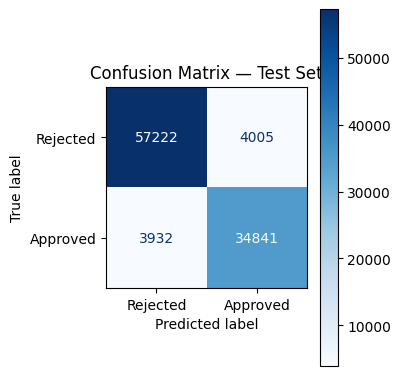

In [12]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['Rejected', 'Approved'],
    cmap=plt.cm.Blues, ax=ax
)
ax.set_title('Confusion Matrix — Test Set')
fig.tight_layout()
plt.savefig(f"{IMAGE_DIR}/confusion_matrix.jpg", bbox_inches='tight')
plt.show()

## 7. Quality Gate

Same thresholds as `scripts/evaluate_model.py`. This cell fails loudly if the model would not pass the production gate.

In [13]:
ACCURACY_THRESHOLD     = 0.80
PRECISION_THRESHOLD    = 0.75
RECALL_THRESHOLD       = 0.75
F1_THRESHOLD           = 0.75
FAIRNESS_GAP_THRESHOLD = 0.20

all_metrics_flat = {
    **{f'train_{k}': v for k, v in train_metrics.items()},
    **{f'test_{k}':  v for k, v in test_metrics.items()},
    **fairness,
}

checks = [
    ('test_accuracy',  all_metrics_flat['test_accuracy'],  ACCURACY_THRESHOLD,     '>='),
    ('test_precision', all_metrics_flat['test_precision'], PRECISION_THRESHOLD,    '>='),
    ('test_recall',    all_metrics_flat['test_recall'],    RECALL_THRESHOLD,       '>='),
    ('test_f1',        all_metrics_flat['test_f1'],        F1_THRESHOLD,           '>='),
    ('fairness_gap',   all_metrics_flat['fairness_gap'],   FAIRNESS_GAP_THRESHOLD, '<'),
]

print(f"{'='*60}")
print(f"  Quality & Fairness Gate")
print(f"{'='*60}")
violations = []
for name, value, threshold, op in checks:
    passed = (value >= threshold) if op == '>=' else (value < threshold)
    status = 'PASS' if passed else 'FAIL'
    mark   = '✓' if passed else '✗'
    print(f"  [{status}] {mark} {name:<22} = {value:.4f}  (threshold {op} {threshold})")
    if not passed:
        violations.append(f"{name} = {value:.4f} fails threshold {op} {threshold}")
print(f"{'='*60}")

if violations:
    print("\n  GATE: FAILED")
    for v in violations:
        print(f"    - {v}")
    raise AssertionError("Model failed the quality/fairness gate. See violations above.")
else:
    print("\n  GATE: PASSED")

  Quality & Fairness Gate
  [PASS] ✓ test_accuracy          = 0.9206  (threshold >= 0.8)
  [PASS] ✓ test_precision         = 0.9207  (threshold >= 0.75)
  [PASS] ✓ test_recall            = 0.9206  (threshold >= 0.75)
  [PASS] ✓ test_f1                = 0.9206  (threshold >= 0.75)
  [FAIL] ✗ fairness_gap           = 0.2576  (threshold < 0.2)

  GATE: FAILED
    - fairness_gap = 0.2576 fails threshold < 0.2


AssertionError: Model failed the quality/fairness gate. See violations above.

## 8. Save Artifacts

In [14]:
model_path   = f"{OUTPUT_DIR}/model.joblib"
metrics_path = f"{OUTPUT_DIR}/metrics.json"

joblib.dump(model, model_path)

with open(metrics_path, 'w') as f:
    json.dump(all_metrics_flat, f, indent=2)

print(f"Model   saved → {model_path}")
print(f"Metrics saved → {metrics_path}")
print()
print("To test the Flask API locally with this model:")
print(f"  cd deployment/api")
print(f"  MODEL_SOURCE=local MODEL_LOCAL_PATH=../../{model_path} python app.py")

Model   saved → outputs/model.joblib
Metrics saved → outputs/metrics.json

To test the Flask API locally with this model:
  cd deployment/api
  MODEL_SOURCE=local MODEL_LOCAL_PATH=../../outputs/model.joblib python app.py


## 9. Track with MLFlow

Logs to the MLFlow tracking URI from `configs/config.yml`. If the remote server is unreachable, set `MLFLOW_TRACKING_URI=mlruns` before running to use a local file store instead.

In [15]:
tracking_uri = os.environ.get('MLFLOW_TRACKING_URI', MLFLOW_URI)
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run() as run:
    # Parameters
    mlflow.log_params({
        'n_estimators':  N_ESTIMATORS,
        'n_features':    X.shape[1],
        'feature_names': list(X.columns),
    })

    # Metrics
    for k, v in all_metrics_flat.items():
        if isinstance(v, float):
            mlflow.log_metric(k, v)

    # Model artifact
    mlflow.sklearn.log_model(model, 'model')

    # Chart artifacts
    for img in pathlib.Path(IMAGE_DIR).glob('*.jpg'):
        mlflow.log_artifact(str(img), artifact_path='charts')

    run_id = run.info.run_id

print(f"MLFlow run ID : {run_id}")
print(f"Tracking URI  : {tracking_uri}")

2026/03/18 12:31:55 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/18 12:31:57 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/18 12:31:59 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/18 12:32:00 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/18 12:32:01 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/18 12:32:03 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/18 12:32:03 WARNING mlflow.tracking.request_header.regis

🏃 View run magnificent-wasp-716 at: https://mlflow.sandbox.harness-demo.site/#/experiments/1/runs/928d23f908f24c9690ac0eb92e0856d3
🧪 View experiment at: https://mlflow.sandbox.harness-demo.site/#/experiments/1


MlflowException: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: '<!doctype html>
<html lang=en>
<title>404 Not Found</title>
<h1>Not Found</h1>
<p>The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.</p>
'